# Soft Sensor para Planta de Tratamiento de Aguas Residuales

**Curso:** ETL y Ciencia de Datos — Semestre 2026-1
**Línea:** Ciencia de Datos e IA
**Enfoque:** Pipeline ETL para preparación de datos SCADA del proceso de aireación

---

## Objetivo

Desarrollar un pipeline de **Extracción, Transformación y Carga (ETL)** que procese los datos históricos del sistema SCADA de una planta de tratamiento de aguas residuales. Los datos contienen 105,409 registros cada 5 minutos del proceso de aireación durante 366 días (Nov 2023 - Nov 2024).

El alcance comprende **exclusivamente el proceso ETL**; la construcción de modelos predictivos (soft sensors) queda como trabajo futuro.

---

## 0. Configuración del Entorno

In [ ]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, json
from datetime import datetime

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
print('✓ Librerías cargadas')

✓ Librerías cargadas


### Ruta del archivo

Sube el archivo `AmmoniaModelDataWitB1C7AmmoniumHuman.csv` a Google Drive

In [ ]:
# CONFIGURAR RUTAS
FILEPATH = '/content/drive/MyDrive/ETL/ProyectoFinal/AmmoniaModelDataWitB1C7AmmoniumHuman.csv'

OUTPUT_DIR = '/content/drive/MyDrive/ETL/ProyectoFinal'

## 1. Configuración Global

Mapeo de columnas SCADA a nombres limpios y rangos físicos válidos para detección de outliers.

Los datos del archivo CSV ya vienen en **unidades de ingeniería reales** (mg/L, PSI, SCFM, GPM, MGD, °F, °C), exportados directamente del sistema SCADA sin factores de escala.

In [ ]:
# MAPEO DE COLUMNAS
COLUMN_RENAME = {
    'DateTime': 'timestamp',
    'Air Header 2 Pressure': 'air_header_pressure_psi',
    'Air Header 1 Temperature': 'air_header_temp_f',
    'Flow Distribution Structure Ammonium': 'influent_ammonium_mg_l',
    'Aeration Basin 1 Cell 5 D O': 'do_basin1_mg_l',
    'Aeration Basin 2 Cell 5 D O': 'do_basin2_mg_l',
    'Aeration Basin 3 Cell 5 D O': 'do_basin3_mg_l',
    'Aeration Basin 4 Cell 5 D O': 'do_basin4_mg_l',
    'Aeration Basin 5 Cell 5 D O': 'do_basin5_mg_l',
    'Aeration Basin 6 Cell 5 D O': 'do_basin6_mg_l',
    'Aeration Basin 1 Airflow to Cells 1-6': 'airflow_basin1_cells1_6_scfm',
    'Aeration Basin 1 Air Flow to Cells 7-10': 'airflow_basin1_cells7_10_scfm',
    'Aeration Basin 2 Airflow to Cells 1-6': 'airflow_basin2_cells1_6_scfm',
    'Aeration Basin 2 Air Flow to Cells 7-10': 'airflow_basin2_cells7_10_scfm',
    'Aeration Basin 3 Airflow to Cells 1-6': 'airflow_basin3_cells1_6_scfm',
    'Aeration Basin 3 Air Flow to Cells 7-10': 'airflow_basin3_cells7_10_scfm',
    'Aeration Basin 4 Airflow to Cells 1-6': 'airflow_basin4_cells1_6_scfm',
    'Aeration Basin 4 Air Flow to Cells 7-10': 'airflow_basin4_cells7_10_scfm',
    'Aeration Basin 5 Airflow to Cells 1-6': 'airflow_basin5_cells1_6_scfm',
    'Aeration Basin 5 Cells 7-10 Airflow': 'airflow_basin5_cells7_10_scfm',
    'Aeration Basin 6 Airflow to Cells 1-6': 'airflow_basin6_cells1_6_scfm',
    'Aeration Basin 6 Cells 7-10 Airflow': 'airflow_basin6_cells7_10_scfm',
    'Sum of F30402 and F30403, with addition of RAS Flow to Basins': 'total_influent_flow_mgd',
    'Total Ras Flow': 'total_ras_flow_gpm',
    'Total MLR Flow': 'total_mlr_flow_mgd',
    'Aeration Effluent Channel Ammonium': 'effluent_ammonium_mg_l',
    'Aeration Effluent Channel Phosphate': 'effluent_phosphate_mg_l',
    'Aeration Effluent Channel Suspended Solids': 'effluent_ss',
    'Aeration Basin Effluent Channel Temp': 'effluent_temp_c',
    'Aeration Basin Eff Channel pH': 'effluent_ph',
    'Aeration Basin 1 Cell 7 Ammonium': 'basin1_cell7_ammonium_mg_l',
}

In [ ]:
# RANGOS FÍSICOS VÁLIDOS
VALID_RANGES = {
    'air_header_pressure_psi': (2.0, 15.0),
    'air_header_temp_f': (50.0, 300.0),
    'influent_ammonium_mg_l': (0.0, 200.0),
    'do_basin1_mg_l': (0.0, 15.0), 'do_basin2_mg_l': (0.0, 15.0),
    'do_basin3_mg_l': (0.0, 15.0), 'do_basin4_mg_l': (0.0, 15.0),
    'do_basin5_mg_l': (0.0, 15.0),
    'effluent_ammonium_mg_l': (0.0, 50.0),
    'effluent_phosphate_mg_l': (0.0, 20.0),
    'effluent_temp_c': (0.0, 40.0),
    'effluent_ph': (4.0, 10.0),
    'basin1_cell7_ammonium_mg_l': (0.0, 50.0),
    'total_ras_flow_gpm': (0.0, 15000.0),
    'total_mlr_flow_mgd': (0.0, 100.0),
    'total_influent_flow_mgd': (0.0, 100.0),
}

---
## 2. FASE 1: Extracción

Lectura del archivo CSV exportado del SCADA e inspección del estado de los datos crudos.

In [ ]:
# EXTRACCIÓN
print('Leyendo archivo CSV del SCADA...')
df = pd.read_csv(FILEPATH)

print(f'\n  Filas:    {len(df):,}')
print(f'  Columnas: {len(df.columns)}')
print(f'  Memoria:  {df.memory_usage(deep=True).sum()/1e6:.1f} MB')

metadata = {'archivo_fuente': os.path.basename(FILEPATH), 'fecha_extraccion': datetime.now().isoformat(), 'filas_extraidas': len(df), 'columnas_extraidas': len(df.columns)}

Leyendo archivo CSV del SCADA...

  Filas:    105,409
  Columnas: 31
  Memoria:  32.0 MB


In [ ]:
# Tipos de datos
print('Tipos de datos por columna:')
print('=' * 65)
for col in df.columns:
    print(f'  {col[:50]:50s} | {str(df[col].dtype)}')
print(f'\n→ Todos los tipos son numéricos (float64/int64) excepto DateTime (string)')

Tipos de datos por columna:
  DateTime                                           | object
  Air Header 2 Pressure                              | float64
  Air Header 1 Temperature                           | float64
  Flow Distribution Structure Ammonium               | float64
  Aeration Basin 1 Cell 5 D O                        | float64
  Aeration Basin 2 Cell 5 D O                        | float64
  Aeration Basin 3 Cell 5 D O                        | float64
  Aeration Basin 4 Cell 5 D O                        | float64
  Aeration Basin 5 Cell 5 D O                        | float64
  Aeration Basin 6 Cell 5 D O                        | float64
  Aeration Basin 1 Airflow to Cells 1-6              | float64
  Aeration Basin 1 Air Flow to Cells 7-10            | float64
  Aeration Basin 2 Airflow to Cells 1-6              | float64
  Aeration Basin 2 Air Flow to Cells 7-10            | float64
  Aeration Basin 3 Airflow to Cells 1-6              | float64
  Aeration Basin 3 Air Flow 

In [ ]:
# Valores nulos
print('Valores nulos en datos crudos:')
print('=' * 65)
for col in df.columns:
    n = df[col].isnull().sum()
    if n > 0:
        print(f'  {col[:50]:50s} | {n:6d} ({n/len(df)*100:.3f}%)')
print(f'\n→ Total: {df.isnull().sum().sum():,} nulos')

Valores nulos en datos crudos:
  Air Header 2 Pressure                              |     64 (0.061%)
  Air Header 1 Temperature                           |     64 (0.061%)
  Flow Distribution Structure Ammonium               |     16 (0.015%)
  Aeration Basin 1 Cell 5 D O                        |     17 (0.016%)
  Aeration Basin 2 Cell 5 D O                        |     17 (0.016%)
  Aeration Basin 3 Cell 5 D O                        |     64 (0.061%)
  Aeration Basin 4 Cell 5 D O                        |     64 (0.061%)
  Aeration Basin 5 Cell 5 D O                        |     16 (0.015%)
  Aeration Basin 6 Cell 5 D O                        |     59 (0.056%)
  Aeration Basin 1 Airflow to Cells 1-6              |     17 (0.016%)
  Aeration Basin 1 Air Flow to Cells 7-10            |     64 (0.061%)
  Aeration Basin 2 Airflow to Cells 1-6              |     17 (0.016%)
  Aeration Basin 2 Air Flow to Cells 7-10            |     64 (0.061%)
  Aeration Basin 3 Airflow to Cells 1-6       

In [ ]:
# Muestra de datos crudos
df.head()

,DateTime,Air Header 2 Pressure,Air Header 1 Temperature,Flow Distribution Structure Ammonium,Aeration Basin 1 Cell 5 D O,Aeration Basin 2 Cell 5 D O,Aeration Basin 3 Cell 5 D O,Aeration Basin 4 Cell 5 D O,Aeration Basin 5 Cell 5 D O,Aeration Basin 6 Cell 5 D O,...,Aeration Basin 6 Cells 7-10 Airflow,"Sum of F30402 and F30403, with addition of RAS Flow to Basins",Total Ras Flow,Total MLR Flow,Aeration Effluent Channel Ammonium,Aeration Effluent Channel Phosphate,Aeration Effluent Channel Suspended Solids,Aeration Basin Effluent Channel Temp,Aeration Basin Eff Channel pH,Aeration Basin 1 Cell 7 Ammonium
0,11/1/2023 0:00,9.10275,162.993744,43.905502,3.01050,0.0,3.30375,2.22150,3.4530,0.0,...,61.048965,20.501894,2009.818726,43.350571,0.0,0.201250,3468.4375,22.5,6.575625,0.2115
1,11/1/2023 0:05,9.11850,162.843750,43.938133,2.83425,0.0,3.28500,2.15025,3.3930,0.0,...,58.886627,5.710332,2204.787598,43.403038,0.0,0.229375,3261.8750,22.5,6.572125,0.2115
2,11/1/2023 0:10,9.12075,162.768753,44.538975,2.93175,0.0,3.30525,2.04600,3.4785,0.0,...,59.956306,4.715540,2523.000000,43.052399,0.0,0.191250,3323.4375,22.5,6.573000,0.1995
3,11/1/2023 0:15,9.10500,162.918747,43.574448,2.98200,0.0,3.25725,2.14575,3.4620,0.0,...,61.042477,13.939616,2034.618774,38.851021,0.0,0.190625,3390.9375,22.5,6.582625,0.1995
4,11/1/2023 0:20,9.11775,162.562500,43.391895,2.93925,0.0,3.23925,2.16225,3.3915,0.0,...,61.018108,17.405180,2261.850098,43.453259,0.0,0.191875,3362.8125,22.5,6.572125,0.1995


---
## 3. FASE 2: Transformación

La transformación incluye **8 pasos secuenciales** que limpian, validan y enriquecen los datos.

### Paso 1: Estandarización de Timestamps

In [ ]:
df['DateTime'] = pd.to_datetime(df['DateTime'], format='mixed')
df = df.dropna(subset=['DateTime']).sort_values('DateTime').reset_index(drop=True)
print(f'Rango: {df["DateTime"].min()} → {df["DateTime"].max()}')
print(f'Duración: {(df["DateTime"].max() - df["DateTime"].min()).days} días')

Rango: 2023-11-01 00:00:00 → 2024-11-01 00:00:00
Duración: 366 días


### Paso 2: Renombramiento de Columnas

In [ ]:
df = df.rename(columns=COLUMN_RENAME)
print(f'{len(COLUMN_RENAME)} columnas renombradas')
for i, col in enumerate(df.columns):
    print(f'  {i+1:2d}. {col}')

31 columnas renombradas
   1. timestamp
   2. air_header_pressure_psi
   3. air_header_temp_f
   4. influent_ammonium_mg_l
   5. do_basin1_mg_l
   6. do_basin2_mg_l
   7. do_basin3_mg_l
   8. do_basin4_mg_l
   9. do_basin5_mg_l
  10. do_basin6_mg_l
  11. airflow_basin1_cells1_6_scfm
  12. airflow_basin1_cells7_10_scfm
  13. airflow_basin2_cells1_6_scfm
  14. airflow_basin2_cells7_10_scfm
  15. airflow_basin3_cells1_6_scfm
  16. airflow_basin3_cells7_10_scfm
  17. airflow_basin4_cells1_6_scfm
  18. airflow_basin4_cells7_10_scfm
  19. airflow_basin5_cells1_6_scfm
  20. airflow_basin5_cells7_10_scfm
  21. airflow_basin6_cells1_6_scfm
  22. airflow_basin6_cells7_10_scfm
  23. total_influent_flow_mgd
  24. total_ras_flow_gpm
  25. total_mlr_flow_mgd
  26. effluent_ammonium_mg_l
  27. effluent_phosphate_mg_l
  28. effluent_ss
  29. effluent_temp_c
  30. effluent_ph
  31. basin1_cell7_ammonium_mg_l


### Paso 3: Eliminación de Columnas sin Información

El sensor de DO del Basin 6 estuvo inactivo (99.9% ceros) durante todo el período.

In [ ]:
zero_pct = (df['do_basin6_mg_l'] == 0).sum() / len(df) * 100
print(f'do_basin6_mg_l: {zero_pct:.1f}% ceros → ELIMINADA')
df = df.drop(columns=['do_basin6_mg_l'])

do_basin6_mg_l: 99.9% ceros → ELIMINADA


### Paso 4: Interpolación de Valores Faltantes

Interpolación lineal para gaps ≤ 30 min (6 registros). Los gaps mayores se preservan como NaN.

In [ ]:
null_before = df.isnull().sum().sum()
print(f'NaN antes: {null_before:,}\n')

for col in df.select_dtypes(include=[np.number]).columns:
    is_null = df[col].isnull()
    if is_null.sum() == 0: continue
    groups = is_null.ne(is_null.shift()).cumsum()
    null_groups = df[is_null].groupby(groups[is_null]).size()
    small = (null_groups <= 6).sum(); large = (null_groups > 6).sum()
    df[col] = df[col].interpolate(method='linear', limit=6)
    r = df[col].isnull().sum()
    if small > 0 or large > 0:
        print(f'  {col[:40]:40s} | gaps≤30min: {small:3d}, gaps>30min: {large:2d}, NaN rest: {r}')

null_after = df.isnull().sum().sum()
print(f'\nNaN después: {null_after:,} (interpolados: {null_before - null_after:,})')

NaN antes: 1,397

  air_header_pressure_psi                  | gaps≤30min:   7, gaps>30min:  2, NaN rest: 42
  air_header_temp_f                        | gaps≤30min:   7, gaps>30min:  2, NaN rest: 42
  influent_ammonium_mg_l                   | gaps≤30min:   6, gaps>30min:  1, NaN rest: 2
  do_basin1_mg_l                           | gaps≤30min:   7, gaps>30min:  1, NaN rest: 2
  do_basin2_mg_l                           | gaps≤30min:   7, gaps>30min:  1, NaN rest: 2
  do_basin3_mg_l                           | gaps≤30min:   7, gaps>30min:  2, NaN rest: 42
  do_basin4_mg_l                           | gaps≤30min:   7, gaps>30min:  2, NaN rest: 42
  do_basin5_mg_l                           | gaps≤30min:   6, gaps>30min:  1, NaN rest: 2
  airflow_basin1_cells1_6_scfm             | gaps≤30min:   7, gaps>30min:  1, NaN rest: 2
  airflow_basin1_cells7_10_scfm            | gaps≤30min:   7, gaps>30min:  2, NaN rest: 42
  airflow_basin2_cells1_6_scfm             | gaps≤30min:   7, gaps>30min:  1,

### Paso 5: Detección y Tratamiento de Outliers

In [ ]:
# Outliers por rangos físicos
print('Outliers por rangos físicos:')
for col, (vmin, vmax) in VALID_RANGES.items():
    if col not in df.columns: continue
    mask = (df[col] < vmin) | (df[col] > vmax)
    n = mask.sum()
    if n > 0:
        df.loc[mask, col] = np.nan
        print(f'  {col[:40]:40s} | {n:6d} ({n/len(df)*100:.2f}%) → NaN')

# Negativos en airflow → valor absoluto
print('\nFlujos de aire negativos (convención SCADA):')
for col in [c for c in df.columns if 'airflow' in c]:
    neg = (df[col] < 0).sum()
    if neg > 0:
        df.loc[df[col] < 0, col] = df.loc[df[col] < 0, col].abs()
        print(f'  {col[:40]:40s} | {neg:6d} → abs()')

# Re-interpolar
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].interpolate(method='linear', limit=6)

Outliers por rangos físicos:
  air_header_pressure_psi                  |     74 (0.07%) → NaN
  effluent_ph                              |    302 (0.29%) → NaN
  total_ras_flow_gpm                       |     30 (0.03%) → NaN
  total_influent_flow_mgd                  |      2 (0.00%) → NaN

Flujos de aire negativos (convención SCADA):
  airflow_basin1_cells1_6_scfm             |   9854 → abs()
  airflow_basin2_cells1_6_scfm             |    162 → abs()
  airflow_basin3_cells1_6_scfm             |    118 → abs()
  airflow_basin4_cells1_6_scfm             |  32368 → abs()
  airflow_basin5_cells1_6_scfm             |    176 → abs()
  airflow_basin6_cells1_6_scfm             |  93964 → abs()


### Paso 6: Validación Temporal

In [ ]:
diffs = df['timestamp'].diff()
gaps = diffs[diffs > pd.Timedelta(minutes=7)]
print(f'Gaps > 7 min: {len(gaps)}')
if len(gaps) > 0:
    for idx in gaps.index:
        print(f'  {df["timestamp"].iloc[idx-1]} → {df["timestamp"].iloc[idx]} ({diffs.iloc[idx]})')

dups = df['timestamp'].duplicated().sum()
if dups > 0:
    df = df.drop_duplicates(subset='timestamp', keep='first')
    print(f'Duplicados eliminados: {dups}')

Gaps > 7 min: 1
  2024-03-10 01:55:00 → 2024-03-10 03:00:00 (0 days 01:05:00)
Duplicados eliminados: 12


### Paso 7: Feature Engineering

24 nuevas columnas: temporales, agregaciones, eficiencia de remoción y estadísticas rolling.

In [ ]:
cols_before = len(df.columns)

# Temporales
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
print('✓ Temporales: hour, day_of_week, month, is_weekend')

# Promedio DO
do_cols = [c for c in df.columns if c.startswith('do_basin') and c.endswith('mg_l')]
df['do_avg_mg_l'] = df[do_cols].mean(axis=1)
print(f'✓ do_avg_mg_l: promedio de {len(do_cols)} basins')

# Flujo total por basin
for i in range(1, 7):
    c16 = f'airflow_basin{i}_cells1_6_scfm'
    c710 = f'airflow_basin{i}_cells7_10_scfm'
    if c16 in df.columns and c710 in df.columns:
        df[f'airflow_basin{i}_total_scfm'] = df[c16] + df[c710]
print('✓ airflow_basinX_total_scfm')

# Eficiencia de remoción
mask = (df['influent_ammonium_mg_l'] > 0.1) & df['effluent_ammonium_mg_l'].notna()
df['nh4_removal_efficiency'] = np.nan
df.loc[mask, 'nh4_removal_efficiency'] = ((df.loc[mask, 'influent_ammonium_mg_l'] - df.loc[mask, 'effluent_ammonium_mg_l']) / df.loc[mask, 'influent_ammonium_mg_l'] * 100)
print('✓ nh4_removal_efficiency (%)')

# Rolling stats
for var in ['effluent_ammonium_mg_l', 'do_avg_mg_l', 'effluent_ph', 'effluent_ss']:
    if var in df.columns:
        df[f'{var}_delta'] = df[var].diff()
        df[f'{var}_rolling_mean_1h'] = df[var].rolling(12, min_periods=6).mean()
        df[f'{var}_rolling_std_1h'] = df[var].rolling(12, min_periods=6).std()
print('✓ Deltas y rolling stats (1h)')

print(f'\n→ {len(df.columns) - cols_before} nuevas características')

✓ Temporales: hour, day_of_week, month, is_weekend
✓ do_avg_mg_l: promedio de 5 basins
✓ airflow_basinX_total_scfm
✓ nh4_removal_efficiency (%)
✓ Deltas y rolling stats (1h)

→ 24 nuevas características


### Paso 8: Validación Final

In [ ]:
total_cells = df.shape[0] * df.shape[1]
total_nulls = df.isnull().sum().sum()
completeness = (1 - total_nulls / total_cells) * 100

print(f'Shape final:    {df.shape}')
print(f'Completitud:    {completeness:.2f}%')

print(f'\nVariables principales:')
for var in ['effluent_ammonium_mg_l','effluent_ph','effluent_ss','do_avg_mg_l','influent_ammonium_mg_l','effluent_temp_c']:
    v = df[var].dropna()
    print(f'  {var[:35]:35s} | mean={v.mean():.2f}, std={v.std():.2f}, min={v.min():.2f}, max={v.max():.2f}')

Shape final:    (105397, 54)
Completitud:    99.96%

Variables principales:
  effluent_ammonium_mg_l              | mean=0.54, std=1.49, min=0.00, max=12.00
  effluent_ph                         | mean=6.39, std=0.26, min=4.00, max=9.99
  effluent_ss                         | mean=3589.01, std=382.82, min=0.00, max=4997.19
  do_avg_mg_l                         | mean=2.49, std=0.66, min=0.26, max=8.97
  influent_ammonium_mg_l              | mean=43.18, std=16.41, min=0.00, max=150.00
  effluent_temp_c                     | mean=20.88, std=4.11, min=0.00, max=26.69


---
## 4. Visualización de Resultados

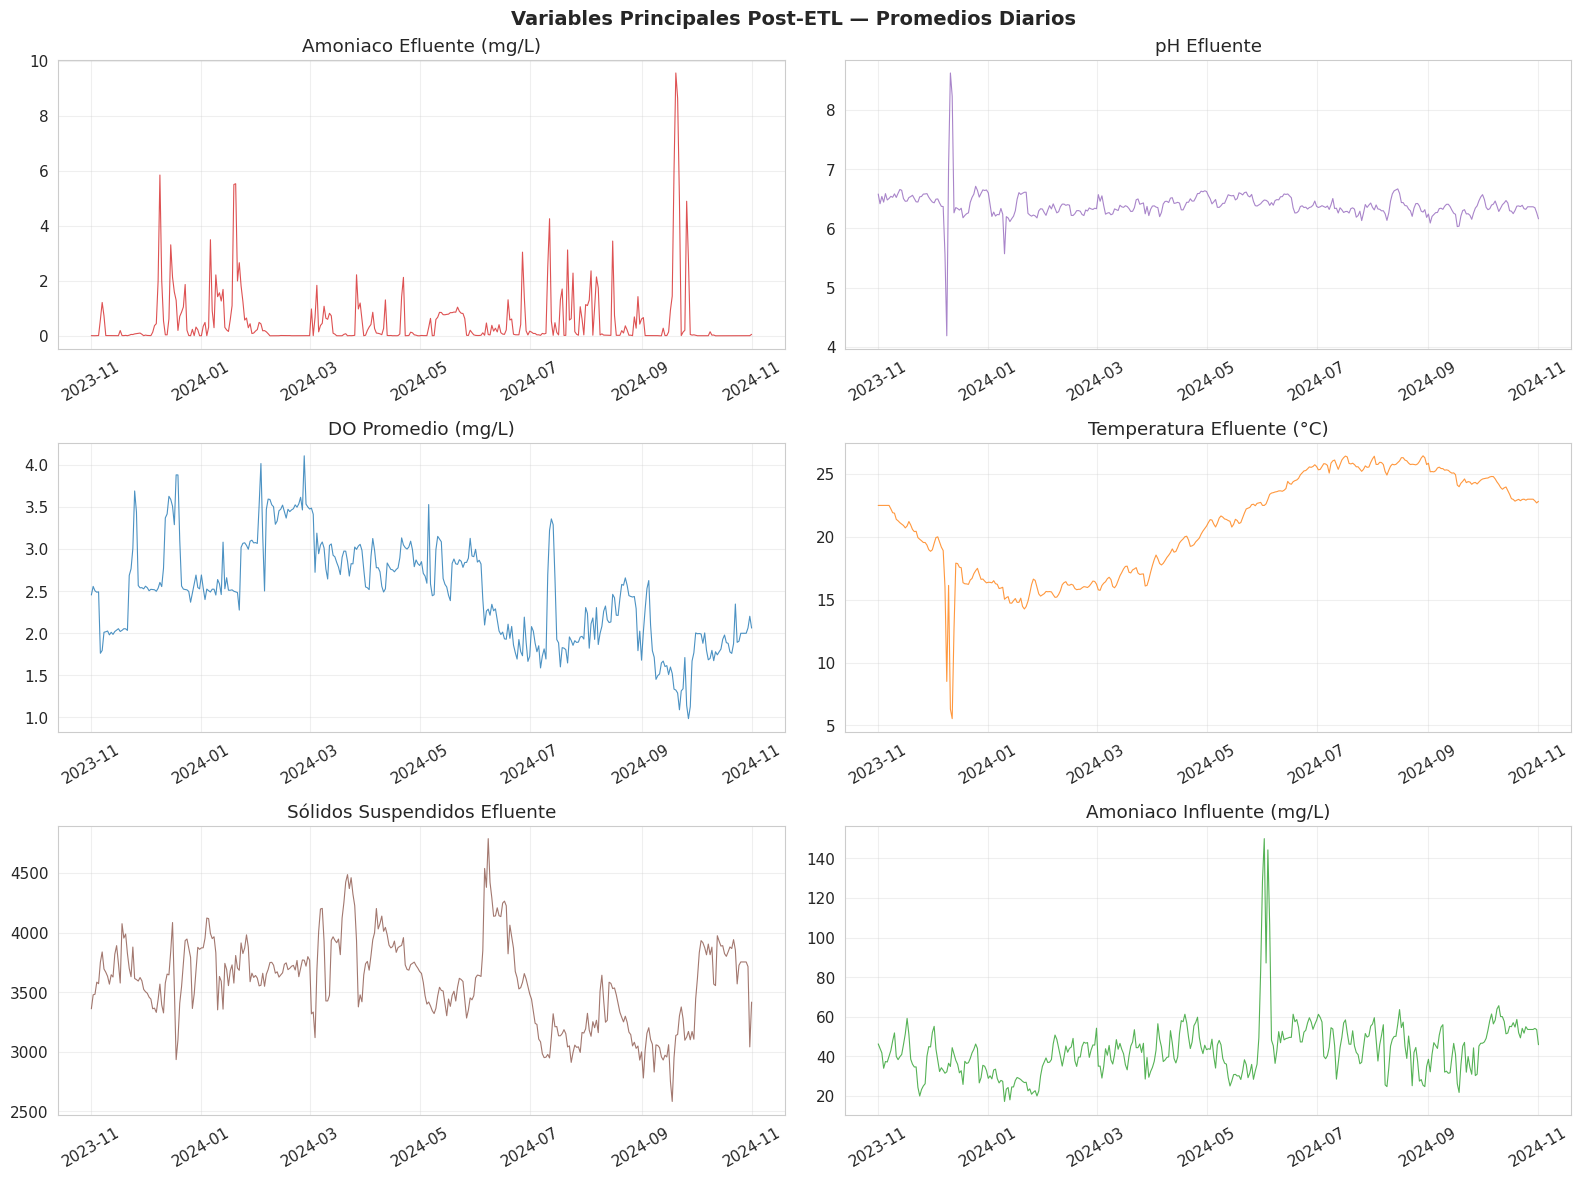

In [ ]:
# Series temporales
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('Variables Principales Post-ETL — Promedios Diarios', fontsize=14, fontweight='bold')

plot_vars = [
    ('effluent_ammonium_mg_l', 'Amoniaco Efluente (mg/L)', 'tab:red'),
    ('effluent_ph', 'pH Efluente', 'tab:purple'),
    ('do_avg_mg_l', 'DO Promedio (mg/L)', 'tab:blue'),
    ('effluent_temp_c', 'Temperatura Efluente (°C)', 'tab:orange'),
    ('effluent_ss', 'Sólidos Suspendidos Efluente', 'tab:brown'),
    ('influent_ammonium_mg_l', 'Amoniaco Influente (mg/L)', 'tab:green'),
]

df_daily = df.set_index('timestamp').resample('D').mean().reset_index()
for ax, (var, label, color) in zip(axes.flat, plot_vars):
    if var in df_daily.columns:
        ax.plot(df_daily['timestamp'], df_daily[var], color=color, linewidth=0.8, alpha=0.8)
        ax.set_title(label); ax.tick_params(axis='x', rotation=30); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/series_temporales.png', dpi=150, bbox_inches='tight')
plt.show()

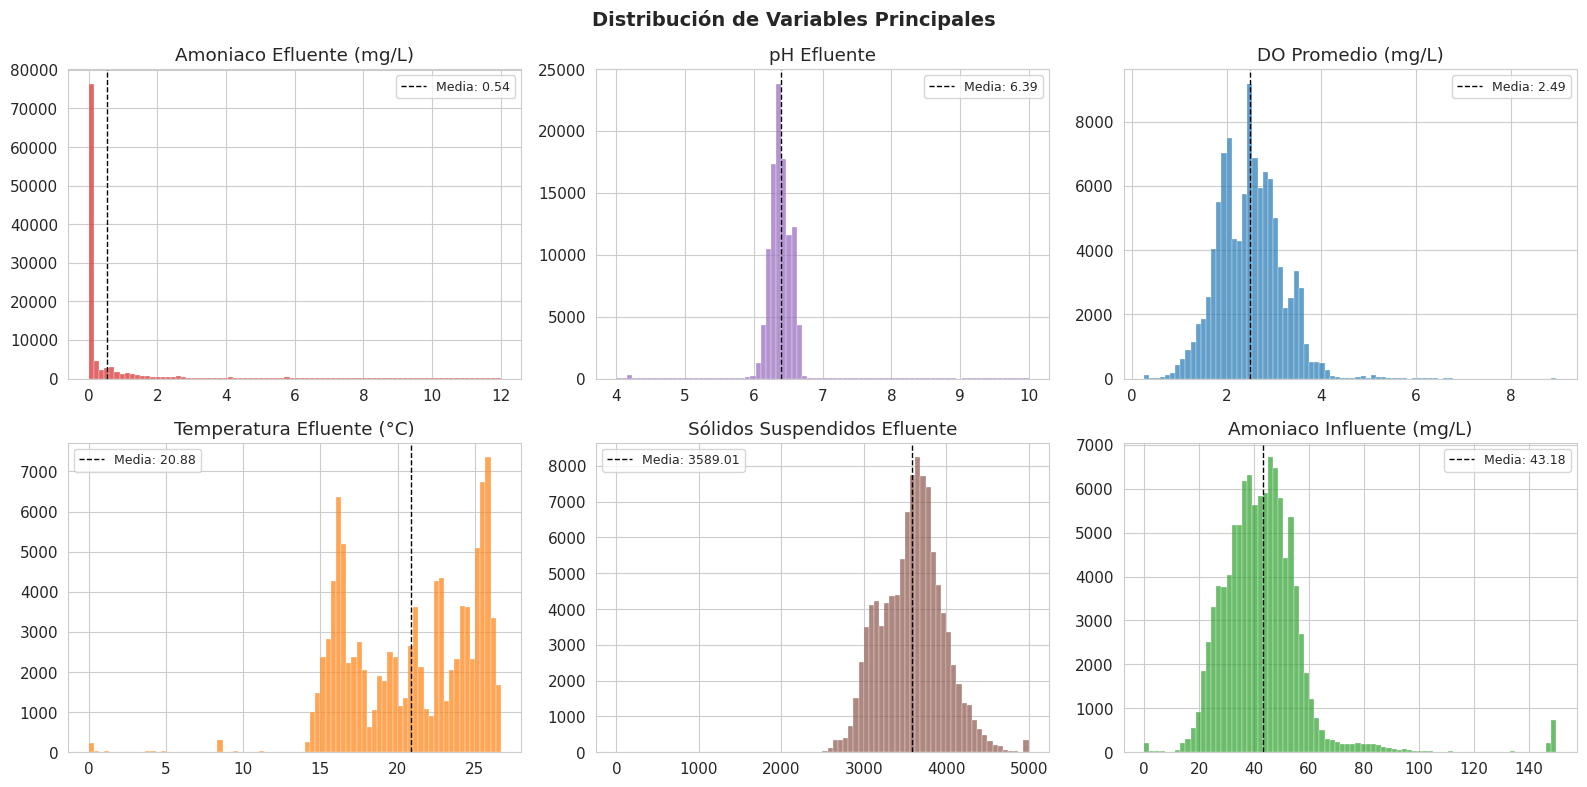

In [ ]:
# Distribuciones
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Distribución de Variables Principales', fontsize=14, fontweight='bold')
for ax, (var, label, color) in zip(axes.flat, plot_vars):
    data = df[var].dropna()
    ax.hist(data, bins=80, color=color, alpha=0.7, edgecolor='white', linewidth=0.3)
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1, label=f'Media: {data.mean():.2f}')
    ax.set_title(label); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/distribuciones.png', dpi=150, bbox_inches='tight')
plt.show()

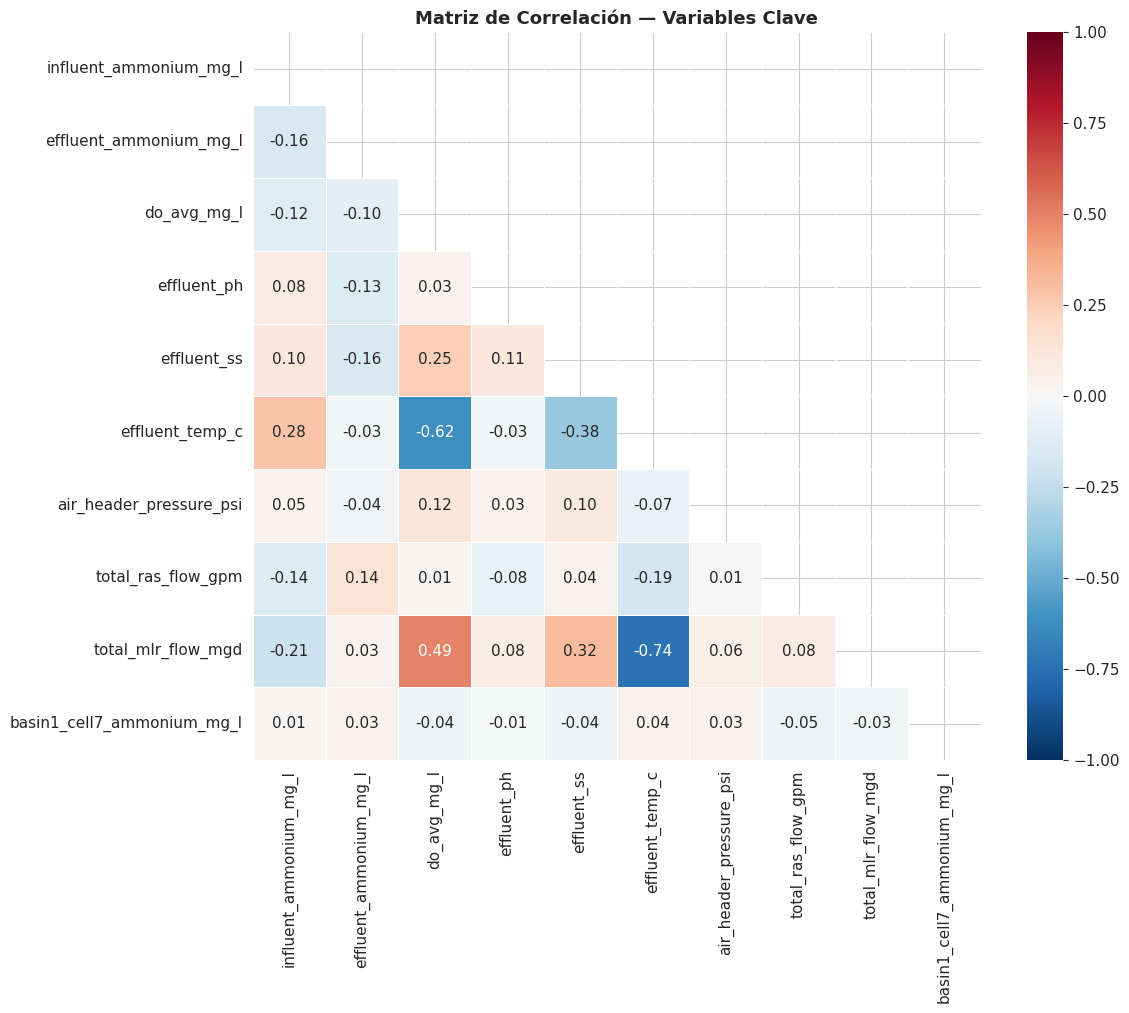

In [ ]:
# Matriz de correlación
corr_vars = [v for v in ['influent_ammonium_mg_l','effluent_ammonium_mg_l','do_avg_mg_l','effluent_ph','effluent_ss','effluent_temp_c','air_header_pressure_psi','total_ras_flow_gpm','total_mlr_flow_mgd','basin1_cell7_ammonium_mg_l'] if v in df.columns]
fig, ax = plt.subplots(figsize=(12, 10))
corr = df[corr_vars].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Matriz de Correlación — Variables Clave', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. FASE 3: Carga

In [ ]:
# Guardar archivos
csv_path = f'{OUTPUT_DIR}/wwtp_aeration_processed.csv'
df.to_csv(csv_path, index=False)
csv_size = os.path.getsize(csv_path) / 1e6
print(f' CSV:         {csv_path} ({csv_size:.1f} MB)')

gz_path = f'{OUTPUT_DIR}/wwtp_aeration_processed.csv.gz'
df.to_csv(gz_path, index=False, compression='gzip')
gz_size = os.path.getsize(gz_path) / 1e6
print(f' Gzip:        {gz_path} ({gz_size:.1f} MB)')

stats = df.describe(include='all').T
stats['null_count'] = df.isnull().sum()
stats['null_pct'] = (df.isnull().sum() / len(df) * 100).round(3)
stats.to_csv(f'{OUTPUT_DIR}/data_statistics.csv')
print(f' Estadísticas: {OUTPUT_DIR}/data_statistics.csv')

metadata['carga'] = {
    'filas_finales': len(df),
    'columnas_finales': len(df.columns),
    'completitud_pct': round((1 - df.isnull().sum().sum() / (df.shape[0]*df.shape[1])) * 100, 2),
    'csv_size_mb': round(csv_size, 2),
    'gz_size_mb': round(gz_size, 2),
    'fecha_carga': datetime.now().isoformat(),
}
meta_path = f'{OUTPUT_DIR}/pipeline_metadata.json'
with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False, default=str)
print(f'✓ Metadatos:         {meta_path}')

 CSV:         /content/drive/MyDrive/ETL/ProyectoFinal/wwtp_aeration_processed.csv (69.6 MB)
 Gzip:        /content/drive/MyDrive/ETL/ProyectoFinal/wwtp_aeration_processed.csv.gz (26.7 MB)
 Estadísticas: /content/drive/MyDrive/ETL/ProyectoFinal/data_statistics.csv


---
## 6. Resumen Final

In [ ]:

print('  RESUMEN DEL PIPELINE ETL')

print(f'  Fuente:            {os.path.basename(FILEPATH)}')
print(f'  Período:           Nov 2023 — Nov 2024 (366 días)')
print(f'  Filas extraídas:   {metadata["filas_extraidas"]:,}')
print(f'  Filas finales:     {len(df):,}')
print(f'  Columnas finales:  {len(df.columns)}')
print(f'  Completitud:       {(1-df.isnull().sum().sum()/(df.shape[0]*df.shape[1]))*100:.2f}%')
print(f'  CSV → gzip:        {csv_size:.1f} MB → {gz_size:.1f} MB')

print('\n Pipeline ETL completado exitosamente.')

  RESUMEN DEL PIPELINE ETL
  Fuente:            AmmoniaModelDataWitB1C7AmmoniumHuman.csv
  Período:           Nov 2023 — Nov 2024 (366 días)
  Filas extraídas:   105,409
  Filas finales:     105,397
  Columnas finales:  54
  Completitud:       99.96%
  CSV → gzip:        69.6 MB → 26.7 MB

 Pipeline ETL completado exitosamente.


In [ ]:
# Descargar archivos
from google.colab import files
files.download(f'{OUTPUT_DIR}/wwtp_aeration_processed.csv.gz')
files.download(f'{OUTPUT_DIR}/data_statistics.csv')
files.download(f'{OUTPUT_DIR}/pipeline_metadata.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>